---
title: "# Bootstrap：同一例子的计算核验 {.unnumbered}"
---

本 Notebook 与 v10 定稿讲义配套 (沿用 v05 已确认的 DGP)。先穷举五个数的全部有序样本，再核对随机模拟；随后计算两组斜率差。所有数据均为教学构造或明确给定 DGP 的模拟。无联网下载，无 Stata 依赖。

[返回 Bootstrap 讲义](../../lectures/bootstrap.qmd) · [课程主页](../../index.qmd) · [下载本 Notebook](https://raw.githubusercontent.com/lianxhcn/FinEco/main/notebooks/bootstrap/bootstrap-demo.ipynb)


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image

# 在任务包根目录或 code 子目录打开均可，不写死本机绝对路径。
root = Path.cwd().resolve()
while not (root / "tools/bootstrap" / "bootstrap_core.py").is_file():
    if root == root.parent: raise FileNotFoundError("找不到 FinEco 项目根目录")
    root = root.parent
assert (root / "tools/bootstrap" / "bootstrap_core.py").is_file(), "请在解压后的任务包中打开 Notebook"
sys.path.insert(0, str(root / "tools/bootstrap"))
from bootstrap_core import (X_TINY, tiny_example, group_example,
                            validation_example, write_outputs)
print("Python:", sys.version.split()[0], "NumPy:", np.__version__)

Python: 3.11.14 NumPy: 2.4.2


## 重抽样与随机权重

每行都抽五个记录。没有出现的记录权重为零，出现两次的记录权重为 2/5。加权计算应与直接计算伪样本均值相同。

In [2]:
samples = np.array([[2,2,5,12,12],[4,4,5,5,7],[2,4,7,7,12]], dtype=float)
counts = np.array([[(row == v).sum() for v in X_TINY] for row in samples])
weights = counts / 5
assert np.allclose(weights.sum(axis=1), 1)
assert np.allclose(weights @ X_TINY, samples.mean(axis=1))
display(pd.DataFrame({"伪样本":list(map(tuple,samples)),
                      "计数":list(map(tuple,counts)),
                      "权重":list(map(tuple,weights)),
                      "均值":samples.mean(axis=1)}))

,伪样本,计数,权重,均值
0,"(2.0, 2.0, 5.0, 12.0, 12.0)","(2, 0, 1, 0, 2)","(0.4, 0.0, 0.2, 0.0, 0.4)",6.6
1,"(4.0, 4.0, 5.0, 5.0, 7.0)","(0, 2, 2, 1, 0)","(0.0, 0.4, 0.4, 0.2, 0.0)",5.0
2,"(2.0, 4.0, 7.0, 7.0, 12.0)","(1, 1, 0, 2, 1)","(0.2, 0.2, 0.0, 0.4, 0.2)",6.4


## 精确 Bootstrap 分布与随机模拟

精确枚举的 3125 行是全部等概率结果，不是 3125 次随机抽样。其分布标准差使用分母 3125；随机模拟则用样本标准差估计分布标准差。

In [3]:
tiny, arrays = tiny_example()
assert arrays["all_samples"].shape == (3125, 5)
comparison = pd.DataFrame({
    "精确计算": [tiny["exact_boot_mean"],tiny["exact_boot_se"],tiny["exact_boot_bias"]],
    "9999 次模拟": [tiny["mc_boot_mean"],tiny["mc_boot_se"],tiny["mc_boot_bias"]]
}, index=["Bootstrap 均值","Bootstrap 标准误","Bootstrap 偏差"])
display(comparison)
print("精确百分位数区间:",tiny["exact_percentile_ci"])
print("正态近似区间:",tiny["normal_boot_ci"])
print("常用解析 SE 估计:",tiny["analytical_se_estimate"])
print("注意：Bootstrap SE 不再除以 sqrt(B)。")

,精确计算,9999 次模拟
Bootstrap 均值,6.000000,5.980778
Bootstrap 标准误,1.523155,1.518765
Bootstrap 偏差,0.000000,-0.019222


精确百分位数区间: [3.4, 9.2]
正态近似区间: [3.0146717996155976, 8.985328200384401]
常用解析 SE 估计: 1.7029386365926402
注意：Bootstrap SE 不再除以 sqrt(B)。


## 原假设下的右尾概率

预先设定 H0: mu=4、H1: mu>4。平移原样本再抽样，与对原 Bootstrap 均值减去原样本均值，得到相同中心化统计量。这里未学生化，以展示原假设构造；不据此声称小样本检验精确有效。

In [4]:
mu0 = 4.0
shifted = arrays["all_samples"] - X_TINY.mean() + mu0
assert np.allclose(shifted.mean(axis=1) - mu0, arrays["errors_exact"])
print("穷举右尾次数:",tiny["exact_tail_count"],"/",tiny["K"])
print("精确 Bootstrap 尾概率:",tiny["exact_boot_p"])
print("模拟右尾次数:",tiny["mc_tail_count"])
print("采用 (1+k)/(B+1) 的模拟 p 值:",tiny["mc_boot_p_plus1"])
print("固定数据后的尾概率 Monte Carlo SE:",tiny["mc_tail_mcse"])

穷举右尾次数: 376 / 3125
精确 Bootstrap 尾概率: 0.12032
模拟右尾次数: 1171
采用 (1+k)/(B+1) 的模拟 p 值: 0.1172
固定数据后的尾概率 Monte Carlo SE: 0.0032156943102164847


## 两组斜率差

各组内抽完整记录，保持组别与规模。该数据两组解释变量分布与误差尺度均不同，不能因斜率相等就假定可交换。此处不执行置换检验，也不把其结果标为 bdiff 输出。

In [5]:
group, data, differences = group_example()
display(data.head())
display(pd.Series(group,name="实际计算"))
assert data.groupby("group").size().tolist() == [80,80]
assert group["failures"] == 0

,group,cash,invest
0,0,0.156516,0.058799
1,0,0.101353,0.053736
2,0,0.031745,0.056073
3,0,0.153039,0.114724
4,0,0.041470,0.064022


n0                                                       80
n1                                                       80
B                                                      9999
seed                                                  12345
beta0                                              0.232259
beta1                                              0.584934
difference                                        -0.352675
bootstrap_se                                       0.134066
percentile_ci    [-0.614407766319058, -0.09051510896582593]
true_beta0                                              0.3
true_beta1                                              0.6
data_seed                                             24680
failures                                                  0
Name: 实际计算, dtype: object

## 另设已知总体检查误差分布

这里另设正态总体 N(6,14.5)，n=80。解析真分布用于核验，不是假称知道五点例子的真实总体。

In [6]:
validation, observed, errors = validation_example()
display(pd.Series(validation,name="已知总体实验"))
assert np.isclose(validation["true_se"], np.sqrt(14.5/80))

mu                  6.000000
sigma               3.807887
n                  80.000000
B                9999.000000
seed            97531.000000
sample_mean         5.048938
true_se             0.425735
bootstrap_se        0.389549
Name: 已知总体实验, dtype: float64

## 重建数据表和所有统计图

脚本自动寻找本机中文字体，不附送任何字体文件。每幅图独立生成；图内没有硬编号。

已生成五幅 PNG 数值图：
edf-tiny.png 32231 bytes
group-difference.png 41308 bytes
known-dgp-validation.png 48452 bytes
mean-bootstrap-exact.png 39752 bytes
null-mean-tail.png 40315 bytes


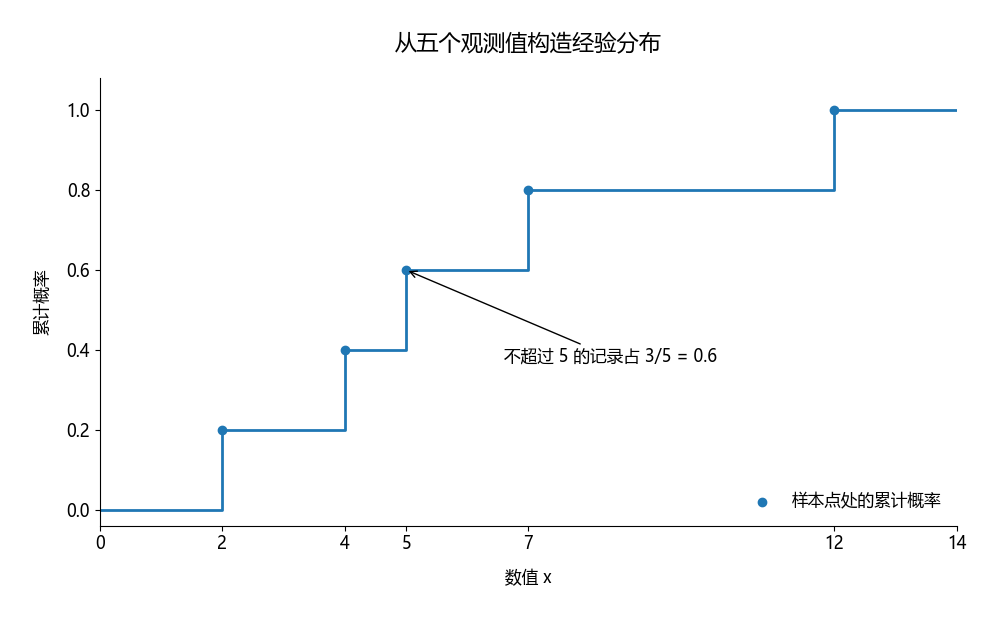

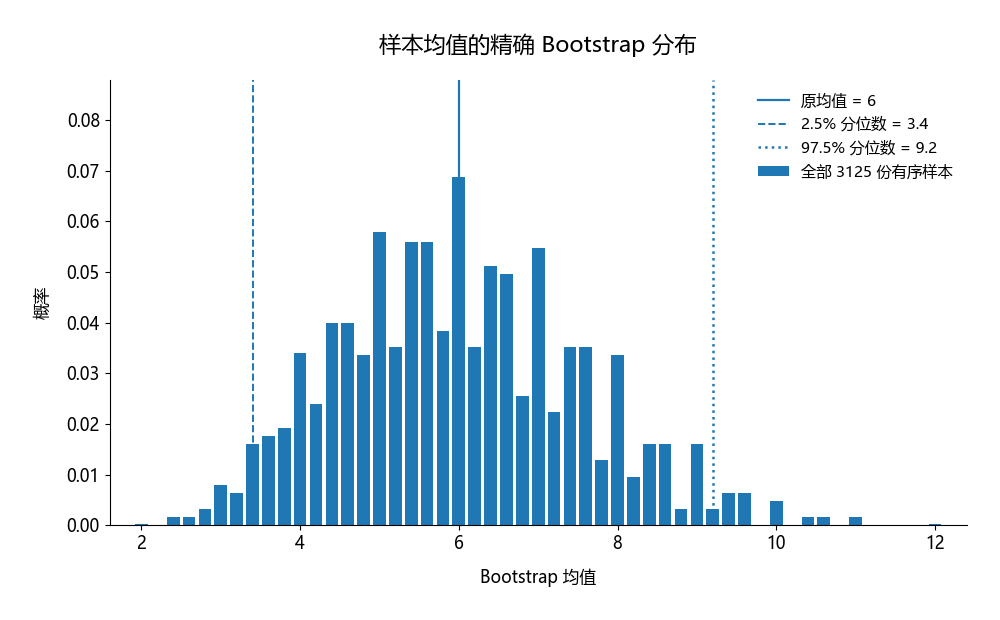

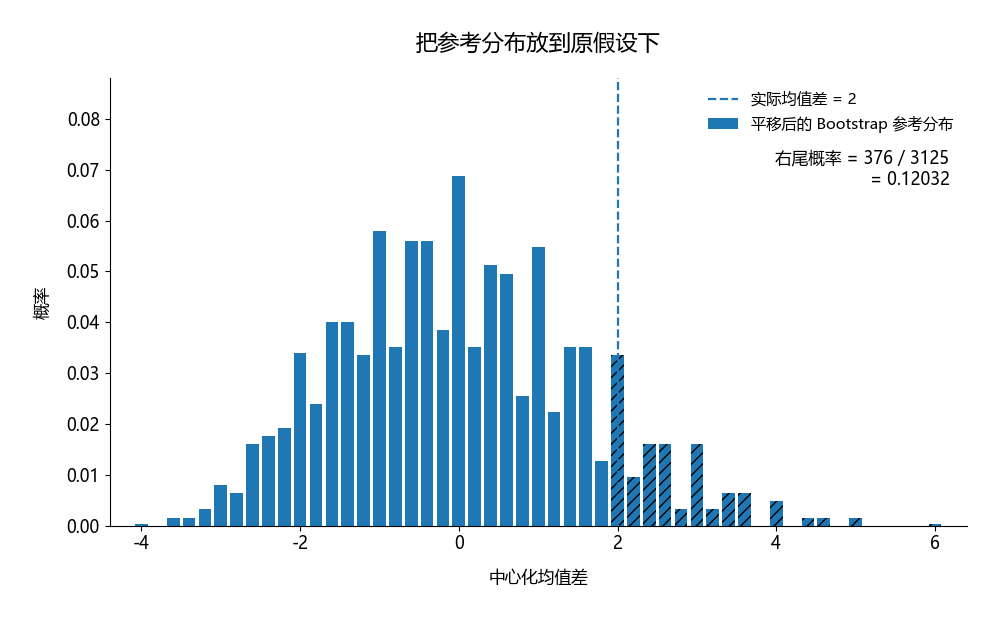

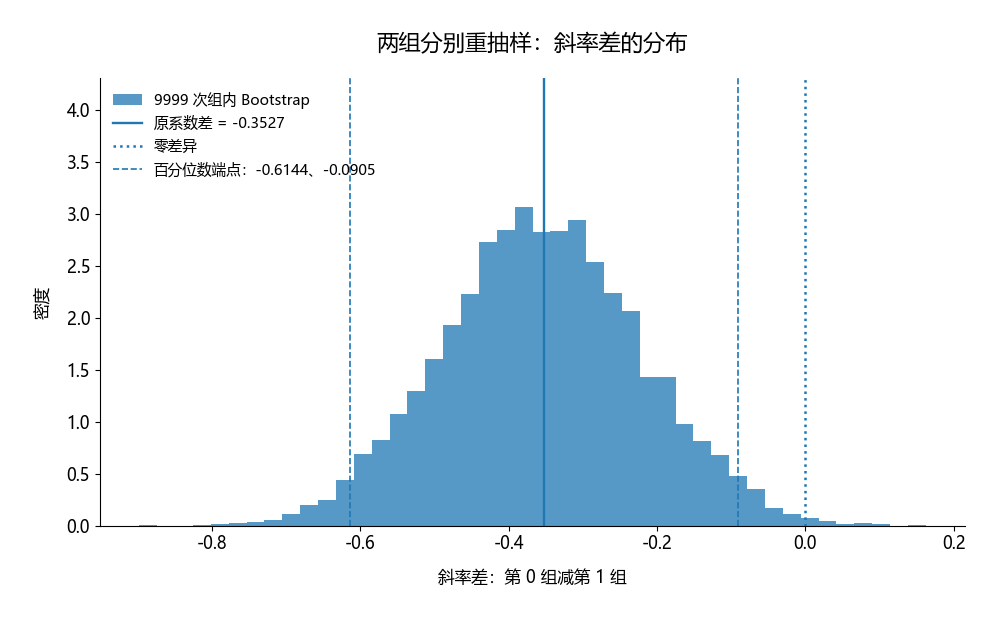

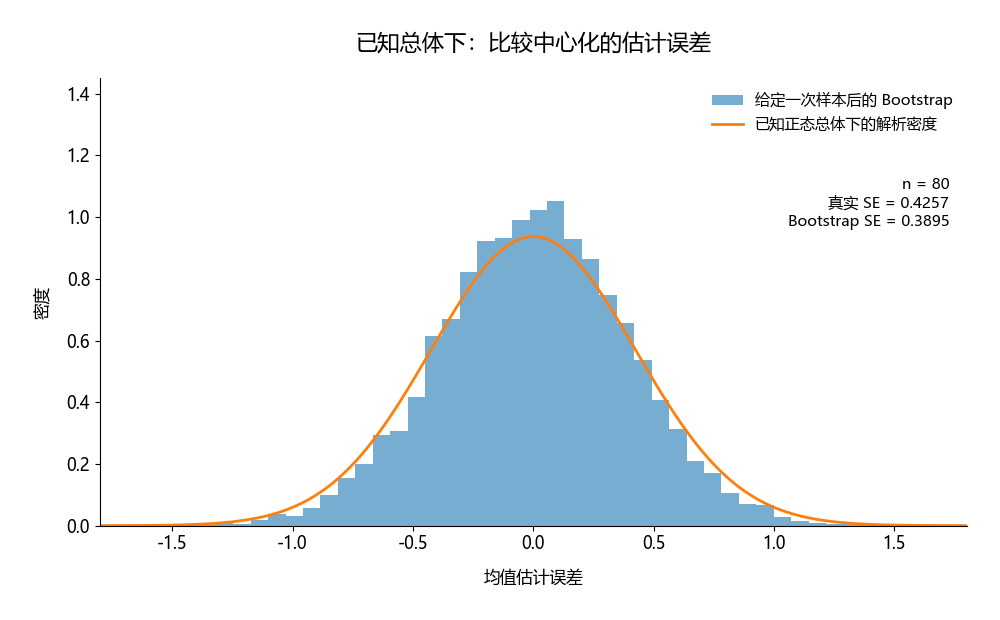

全部计算与图形重建完成。


In [7]:
results = write_outputs()
import make_figures
make_figures.main()
for name in ["edf-tiny.png","mean-bootstrap-exact.png","null-mean-tail.png",
             "group-difference.png","known-dgp-validation.png"]:
    display(Image(filename=str(root/"logs/bootstrap/v10/recomputed"/name)))
print("全部计算与图形重建完成。")